In [90]:
using Pkg

Pkg.activate("..") # From demos/ we go one level up to the project root
#Pkg.instantiate()  # Optional, but recommended to ensure all dependencies are installed

using MiniOps
using Random
using LinearAlgebra
using Plots
using Random 
using SeisProcessing


  Activating project at `~/Dropbox/MiniOps`


(256, 128)
(k, maximum(abs.(r))) = (20, 0.032367035598733884)
(k, maximum(abs.(r))) = (40, 0.04227956259549648)
(k, maximum(abs.(r))) = (60, 0.04713461434402699)
(k, maximum(abs.(r))) = (80, 0.05606491919276424)
(k, maximum(abs.(r))) = (100, 0.06111356872146667)
(k, maximum(abs.(r))) = (120, 0.06414716150955246)
(k, maximum(abs.(r))) = (140, 0.06600783973289515)
(k, maximum(abs.(r))) = (160, 0.06690427422910539)
(k, maximum(abs.(r))) = (180, 0.06729466560569153)
(k, maximum(abs.(r))) = (200, 0.0670994128780732)
(k, maximum(abs.(r))) = (220, 0.0682222919284865)
(k, maximum(abs.(r))) = (240, 0.06951082371691347)
(k, maximum(abs.(r))) = (260, 0.06955363676443205)
(k, maximum(abs.(r))) = (280, 0.06875897723892793)
(k, maximum(abs.(r))) = (300, 0.06788310821585203)


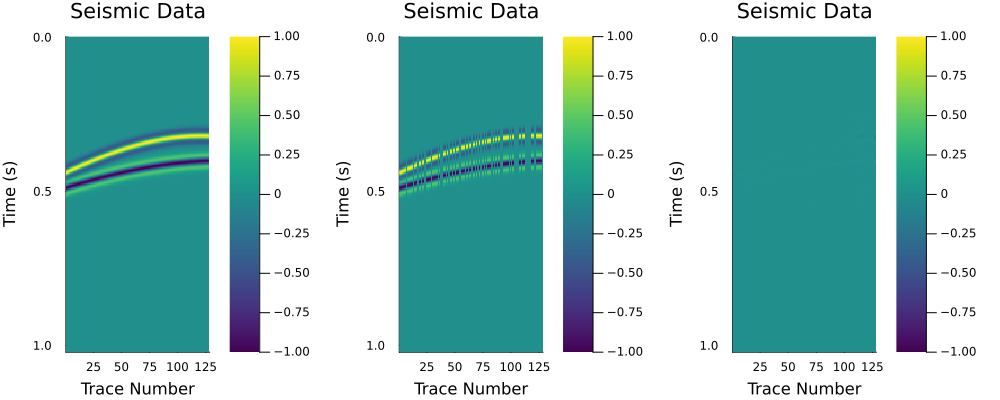

In [86]:
d = SeisHypEvents(nt=256, nx=128, dx = 10.0, vel=[4000.0,5000.0], tau=[0.32,0.40],apex=[200.0,400.0],amp=[1.0,-1.0]); println(size(d))
amax = maximum(abs.(d))
nt, nx = size(d)
dt = 0.004
t = (0:nt-1) .* dt

ns = 80; idx = sort(randperm(nx)[1:ns])


R = sampling_op(idx, (nt,nx)) 
p = 32
P = pad_op((nt,nx),(p,p), (p,p))
y = R*d 

F = fft_op(zeros(ComplexF64,nt+2p,nx+2p)) 
A = R*P'*F; 

  e = opnorm_power(A,randn(ComplexF64,nt+2p,nx+2p)) # Max eigen of C'C 
  ν = 0.98/e^2.  # Step size 
  x2 = ista(A, y, zeros(ComplexF64,nt+2p,nx+2p), 0.003, ν; niter=300, verbose=true);
  drec = real.(P'*F*x2)


p1 = heatmap(
    1:nx, t, d;
    xlabel = "Trace Number",
    ylabel = "Time (s)",
    title = "Seismic Data",
    color = :viridis,
    clims = (-amax, amax),
    yflip = true,
    aspect_ratio = :auto,
    xticks = 0:25:nx-1,
    yticks = 0:0.5:t[end],
)

p2 = heatmap(
    1:nx, t, R'*R*d;
    xlabel = "Trace Number",
    ylabel = "Time (s)",
    title = "Seismic Data",
    color = :viridis,
    clims = (-amax,amax),
    yflip = true,
    aspect_ratio = :auto,
    xticks = 0:25:nx-1,
    yticks = 0:0.5:t[end],
)

p3 = heatmap(
    1:nx, t, drec-d;
    xlabel = "Trace Number",
    ylabel = "Time (s)",
    title = "Seismic Data",
    color = :viridis,
    clims = (-amax,amax),
    yflip = true,
    aspect_ratio = :auto,
    xticks = 0:25:nx-1,
    yticks = 0:0.5:t[end],
)


plot(p1, p2,p3,layout = (1, 3), size = (1000, 400), margins =  4Plots.mm)


In [122]:
d = SeisParabEvents(nt=256, nx1=32, nx2=34, p1=[0.1,2.], p2=[2.3,-0.1], tau=[0.32,0.40],amp=[1.0,-1.0]); println(size(d))

(256, 32, 34)


In [121]:

amax = maximum(abs.(d))
nt, nx, ny = size(d)
dt = 0.004
t = (0:nt-1) .* dt

ns = 1000; idx = sort(randperm(nx*ny)[1:ns])


R = sampling_op(idx, (nt,nx,ny)) 
pt, px, py= (16,4,4)
P = pad_op((nt,nx,ny),(pt,px,py), (pt,px,py))
y = R*d 

F = fft_op(zeros(ComplexF64,nt+2*pt,nx+2*px,ny+2*py)) 
A = R*P'*F; 

  e = opnorm_power(A,randn(ComplexF64,nt+2*pt,nx+2*px,ny+2*py)) # Max eigen of C'C 
  ν = 0.98/e^2.  # Step size 
  x2 = ista(A, y, zeros(ComplexF64,nt+2*pt,nx+2*px,ny+2*py), 0.006, ν; niter = 200, verbose=true);
  drec = real.(P'*F*x2);


(k, maximum(abs.(r))) = (20, 0.1394927662968053)
(k, maximum(abs.(r))) = (40, 0.1734394994060907)
(k, maximum(abs.(r))) = (60, 0.18023583425506118)
(k, maximum(abs.(r))) = (80, 0.1806508732058788)
(k, maximum(abs.(r))) = (100, 0.1810544129087378)
(k, maximum(abs.(r))) = (120, 0.18091469412187122)
(k, maximum(abs.(r))) = (140, 0.18095132351599652)
(k, maximum(abs.(r))) = (160, 0.18095249827427506)
(k, maximum(abs.(r))) = (180, 0.1807668296901681)
(k, maximum(abs.(r))) = (200, 0.18050976989845724)


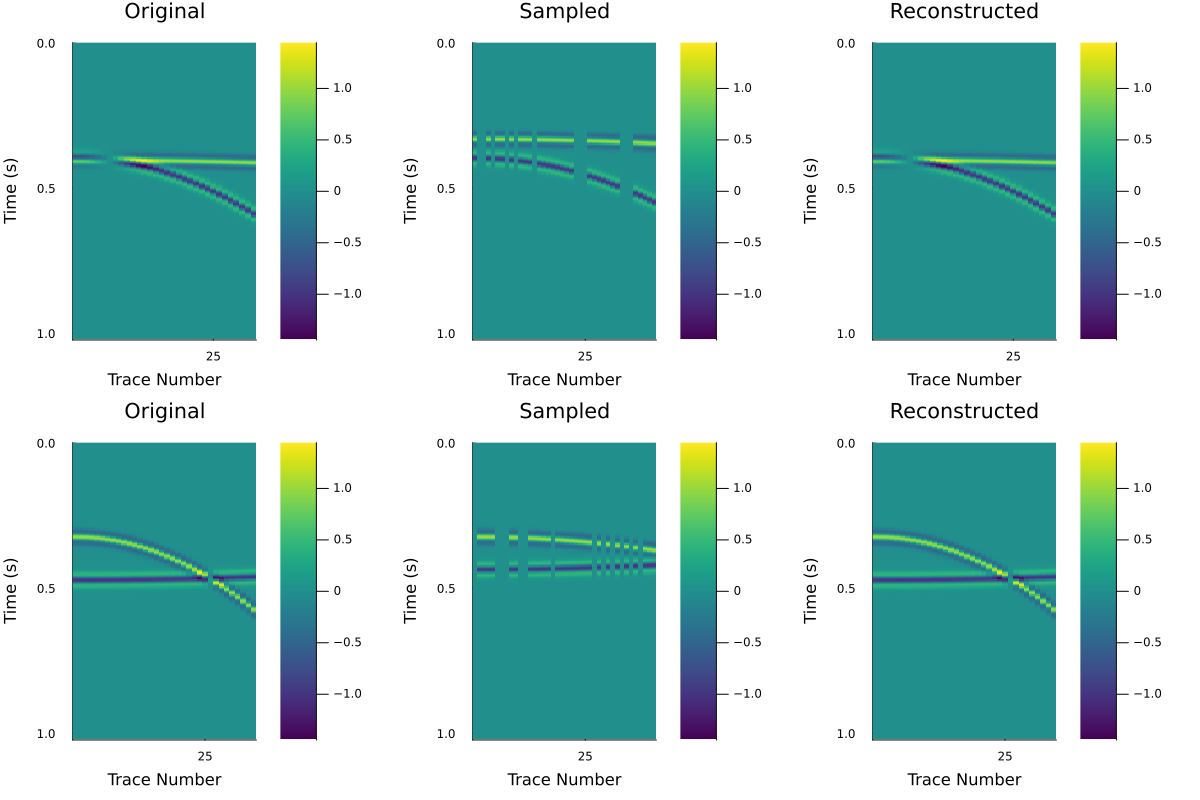

In [119]:
function seismic_plot(x; title="Seismic Data")
    nt,nx=size(x) 
    heatmap(
        1:nx, t, x;
        xlabel = "Trace Number",
        ylabel = "Time (s)",
        title = title,
        color = :viridis,
        clims = (-amax, amax),
        yflip = true,
        aspect_ratio = :auto,
        xticks = 0:25:nx-1,
        yticks = 0:0.5:t[end],
    )
end
p1 = seismic_plot(d[:, :, 20];    title="Original")
p2 = seismic_plot(d0[:, :, 20];   title="Sampled")
p3 = seismic_plot(drec[:, :, 20]; title="Reconstructed")
p4 = seismic_plot(d[:, 20, :];    title="Original")
p5 = seismic_plot(d0[:, 20, :];   title="Sampled")
p6 = seismic_plot(drec[:,20, :]; title="Reconstructed")
plot(p1, p2, p3, p4, p5, p6; layout=(2,3), size=(1200,800), margins=4Plots.mm)

In [120]:
snr = 20*log10(norm(d)/norm(d-drec))

36.162950083537574